In [1]:
%pip install torch torchvision pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\prate\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


________________________________________________________________________________________________________________________________________________________
## Task 1: Vanilla Gradient Saliency Map for Banana Classification

In [6]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

os.environ['TORCH_HOME'] = './torch_weights'
if not os.path.exists('./torch_weights'):
    os.makedirs('./torch_weights')

weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()

print("Model loaded successfully in local directory!")

Model loaded successfully in local directory!


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_path = "banana.jpg"
input_image = Image.open(img_path).convert('RGB')
input_tensor = transform(input_image).unsqueeze(0) 
input_tensor.requires_grad = True 

In [9]:
output = model(input_tensor)

banana_class_idx = 954
score = output[0, banana_class_idx]

model.zero_grad()
score.backward()

gradients = input_tensor.grad.data.abs()

saliency, _ = torch.max(gradients, dim=1)
saliency = saliency.squeeze().numpy()

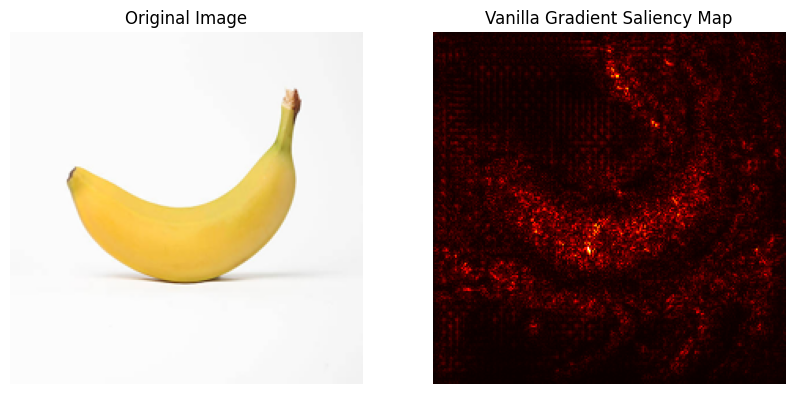

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(input_image.resize((224, 224)))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Vanilla Gradient Saliency Map")
plt.axis('off')

plt.show()

________________________________________________________________________________________________________________________________________________________
## TASK 2: Smooth Visualization via Activation Maximization 

In [11]:
import torch.optim as optim

input_synthetic = torch.randn(1, 3, 224, 224, requires_grad=True)
optimizer = optim.Adam([input_synthetic], lr=0.1)

banana_class_idx = 954

In [12]:
iterations = 200

for i in range(iterations):
    optimizer.zero_grad()
    
    output = model(input_synthetic)
    
    loss = -output[0, banana_class_idx]
    
    loss.backward()
    optimizer.step()
    
    input_synthetic.data.clamp_(0, 1)

    if (i + 1) % 50 == 0:
        print(f"Iteration {i+1}/{iterations} - Banana Score: {-loss.item():.2f}")

print("Optimization complete!")

Iteration 50/200 - Banana Score: 126.64
Iteration 100/200 - Banana Score: 165.96
Iteration 150/200 - Banana Score: 186.30
Iteration 200/200 - Banana Score: 200.71
Optimization complete!


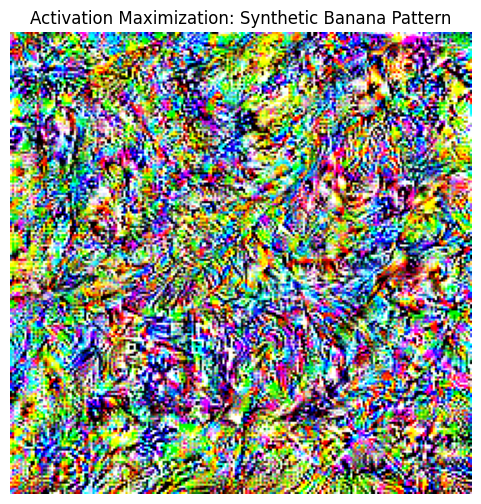

In [13]:
generated_img = input_synthetic.detach().squeeze().permute(1, 2, 0).numpy()

generated_img = (generated_img - generated_img.min()) / (generated_img.max() - generated_img.min())

plt.figure(figsize=(6, 6))
plt.imshow(generated_img)
plt.title("Activation Maximization: Synthetic Banana Pattern")
plt.axis('off')
plt.show()